## Experiment 3.1
In this part af assignment we will implement several Learning-To-Rank model and will compane there performance to each other. 

Details to algorithms that we will cover in this experiment.

### LambdaMART
It is well known algotithm in the learning-to-rank domain. This is an extension to MART gradient boosting framework, incorporation LambdaRank, which optimizes for ranking metrics like NDCG (Normalized Discounted Cumulative Gain) directly.

We will implement custom-solution to understand how it works on baseline, but will use ready-to-use packed solution to achieve better results, since optimisations used in rredy-to-use algotithm a quite complex to implement in context of this task.

### Neural RankNet
Second model we will cover is Neural Rank Net

Neural RankNet is a deep learning-based approach to learning-to-rank problems. It extends the traditional RankNet model by using a neural network to model the ranking function. Neural networks are flexible and can capture complex patterns in the data, potentially leading to better performance on complex tasks.

## Data preparation
We will use our solution to download dataset, that covered in `README.md`. As usial we use dataset MovieLens, provided on it's official page.

In [2]:
import pandas as pd

In [3]:
original_df = pd.read_csv('../../data/ml-1m/ratings.dat', sep='::', header=None, names=['UserID', 'MovieID', 'Rating', 'Timestamp'], engine='python', encoding='latin-1')

In [4]:
df = original_df.copy()
df.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


## LambdaMART

Let's begin from our first algoritm.

**LambdaMART** algorithm that combines the principes of LambdaRank - a gradient optimization technique for ranking. And MART(Multiple Additive Regression Trees, or Gradient Boosting Trees). The main idea behind this technique to optimize a ranking-specific loss function (NDCG) by adjusting the ranking ot items in a pairwise manner.

Now let's dive in to an algorithm implementation more precise.

I'll be describe algorithm step-by-step to readability concerns.

### Step-by-Step Description
1. Initialization
    * Set up initial predictions to all items: $\hat{y}_{i} = 0$ for all items $i$.
    * Initialize the model by setting $\hat{F}_{0}(x) = 0$, where $\hat{F}_{m}(x)$ is the predictions of $m$-th iteration

2. Compute an NDCG and Lambdas
    * For each pair of items(userId, movieId in our case) wee should compute an NDCG loss if there predicted ranks were swapped
    $\Delta\mathrm{NDCG}_{ij}=\mathrm{NDCG}(\mathrm{swap}(i,j))-\mathrm{NDCG}(\mathrm{current})$
    * Compute the probability of the predicted ranks
    $\rho_{ij}=\frac{1}{1+e^{-\sigma(\tilde{y}_{i}-\tilde{y}_{j})}}$
    * Compute Lambda for each pair
    $\lambda_{ij}=-\rho_{ij}\cdot\Delta\mathrm{NDCG}_{ij}$
    * Aggregate lambdas for each item
    $\lambda_{i}=\sum_{j}\lambda_{ij}$
    
3. Fit a regression tree
    * In this step we should fit a regression tree($h_m(x)$) using the computed lambdas($\lambda_i$), where $x$ represents number of features. This tree will be used to predict the gradient of the loss function.
  
4. Update predictions
    * We should update predictions for the next iteration
    $\hat{F}_{m+1}(x)=\hat{F}_{m}(x)+\eta\cdot h_{m}(x)$
    Where $\eta$ is the learning rate
    
5. Repeat the process for $M$ iterations
6. Finale
    * Compute final predictions as a sum of predictions of all trees
    $$
    \hat{F}(x)=\sum_{m=1}^{M}\eta\cdot h_{m}(x)
    $$
    
Now let's move on to actual implementation of algorithm

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = original_df.copy()

data['Rating'] = data['Rating'].astype(float)
data['UserID'] = data['UserID'].astype('category').cat.codes
data['MovieID'] = data['MovieID'].astype('category').cat.codes

In [6]:
data.head()

,UserID,MovieID,Rating,Timestamp
0,0,1104,5.0,978300760
1,0,639,3.0,978302109
2,0,853,3.0,978301968
3,0,3177,4.0,978300275
4,0,2162,5.0,978824291


In [8]:
# Splitting the data
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Scaling features
scaler = StandardScaler()
train_data['Rating'] = scaler.fit_transform(train_data[['Rating']])
test_data['Rating'] = scaler.transform(test_data[['Rating']])

In [10]:
# Creating training and test datasets
X_train = train_data[['UserID', 'MovieID']]
y_train = train_data['Rating']
X_test = test_data[['UserID', 'MovieID']]
y_test = test_data['Rating']

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
X_test_np = X_test.values if hasattr(X_test, 'values') else X_test
y_test_np = y_test.values if hasattr(y_test, 'values') else y_test

Now we should define helper functions for our custom solutions, we should take in to account that implementing LambdaMART requires several complex techniques and our custom implementation can be explained as an simplified, non optimazed version, the purpose of which to demonstrate basic algorithm implementation.

In [11]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from numba import njit, prange

# Sigmoid function
@njit
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Calculate NDCG
@njit
def dcg(y_true, y_pred):
    order = np.argsort(y_pred)[::-1]
    gain = (2**y_true[order] - 1) / np.log2(np.arange(2, len(y_true) + 2))
    return np.sum(gain)

@njit
def ndcg(y_true, y_pred):
    best_dcg = dcg(y_true, y_true)  # Optimal DCG
    actual_dcg = dcg(y_true, y_pred)  # DCG based on predictions
    return actual_dcg / best_dcg if best_dcg > 0 else 0

# Optimized lambda and gradient computation with batch processing
@njit(parallel=True)
def compute_lambdas(y_true, y_pred, batch_size=1000):
    n = len(y_true)
    lambdas = np.zeros_like(y_pred)
    indices = np.random.choice(n, size=min(batch_size, n), replace=False)
    
    for i in prange(len(indices)):
        for j in prange(i + 1, len(indices)):
            idx_i = indices[i]
            idx_j = indices[j]
            if y_true[idx_i] > y_true[idx_j]:
                delta_ndcg = (1.0 / np.log2(i + 2)) - (1.0 / np.log2(j + 2))
                rho = sigmoid(y_pred[idx_i] - y_pred[idx_j])
                lambda_update = rho * delta_ndcg

                lambdas[idx_i] -= lambda_update
                lambdas[idx_j] += lambda_update
    
    return lambdas

Here we will define a custom model class whith will follow solution we described above.

In [12]:
class CustomLambdaMART:
    def __init__(self, n_estimators=10, learning_rate=0.1, max_depth=3, batch_size=1000):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.batch_size = batch_size
        self.models = []
        self.ndcg_history = []
    
    def fit(self, X, y):
        y = np.array(y)
        y_pred = np.zeros_like(y)
        
        for iteration in range(self.n_estimators):
            lambdas = compute_lambdas(y, y_pred, batch_size=self.batch_size)
            
            model = DecisionTreeRegressor(max_depth=self.max_depth)
            model.fit(X, lambdas)
            y_pred += self.learning_rate * model.predict(X)
            
            ndcg_score_current = ndcg(y, y_pred)
            self.ndcg_history.append(ndcg_score_current)
            
            print(f"Iteration {iteration + 1}/{self.n_estimators}, NDCG: {ndcg_score_current:.4f}")
    
    def predict(self, X):
        y_pred = np.zeros(X.shape[0])
        for model in self.models:
            y_pred += self.learning_rate * model.predict(X)
        return y_pred

In [13]:
custom_lambdamart = CustomLambdaMART(n_estimators=100, learning_rate=0.05, max_depth=4, batch_size=1000)
custom_lambdamart.fit(X_train_np, y_train_np)

Iteration 1/100, NDCG: 0.7978
Iteration 2/100, NDCG: 0.7820
Iteration 3/100, NDCG: 0.7827
Iteration 4/100, NDCG: 0.7825
Iteration 5/100, NDCG: 0.7820
Iteration 6/100, NDCG: 0.7832
Iteration 7/100, NDCG: 0.7836
Iteration 8/100, NDCG: 0.7836
Iteration 9/100, NDCG: 0.7824
Iteration 10/100, NDCG: 0.7822
Iteration 11/100, NDCG: 0.7820
Iteration 12/100, NDCG: 0.7812
Iteration 13/100, NDCG: 0.7812
Iteration 14/100, NDCG: 0.7809
Iteration 15/100, NDCG: 0.7810
Iteration 16/100, NDCG: 0.7810
Iteration 17/100, NDCG: 0.7800
Iteration 18/100, NDCG: 0.7800
Iteration 19/100, NDCG: 0.7798
Iteration 20/100, NDCG: 0.7799
Iteration 21/100, NDCG: 0.7803
Iteration 22/100, NDCG: 0.7805
Iteration 23/100, NDCG: 0.7805
Iteration 24/100, NDCG: 0.7798
Iteration 25/100, NDCG: 0.7801
Iteration 26/100, NDCG: 0.7793
Iteration 27/100, NDCG: 0.7792
Iteration 28/100, NDCG: 0.7794
Iteration 29/100, NDCG: 0.7792
Iteration 30/100, NDCG: 0.7791
Iteration 31/100, NDCG: 0.7788
Iteration 32/100, NDCG: 0.7779
Iteration 33/100,

In [14]:
y_pred_custom_lambdamart = custom_lambdamart.predict(X_test_np)

In [15]:
ndcg_custom_lambdamart = ndcg(y_test_np, y_pred_custom_lambdamart)
print(f'NDCG (Custom LambdaMART): {ndcg_custom_lambdamart}')

NDCG (Custom LambdaMART): 0.7849912747198625


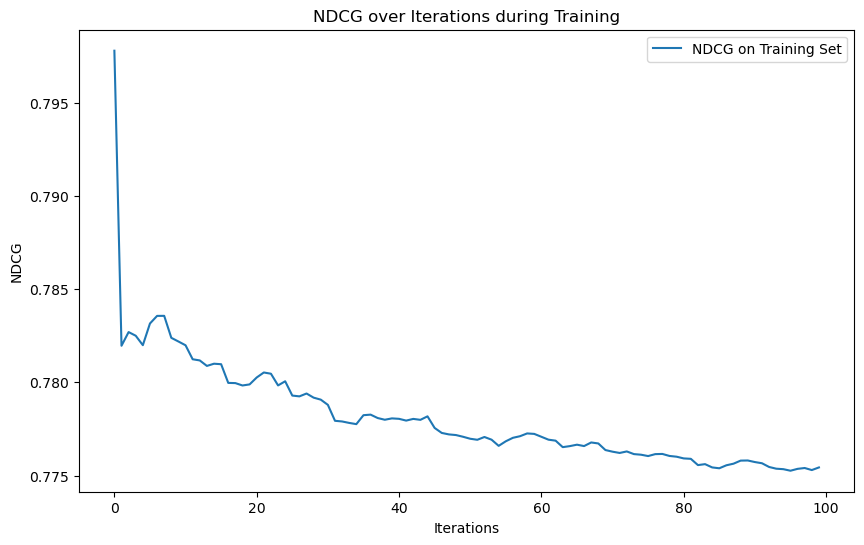

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(custom_lambdamart.ndcg_history, label='NDCG on Training Set')
plt.xlabel('Iterations')
plt.ylabel('NDCG')
plt.title('NDCG over Iterations during Training')
plt.legend()
plt.show()

**NDCG** is quite fine, problem here that our model tents to make worse values, over iterations. Maybe we should to select different parameters in learning process. Let's try to tune model a little.

In [18]:
# Hyperparameter tuning: Experiment with learning rate, number of estimators, and tree depth
best_ndcg = 0.0
best_params = {}
learning_processes = {}

for learning_rate in [0.01, 0.05, 0.1]:
    for n_estimators in [50, 100, 200]:
        for max_depth in [3, 5, 7]:
            model = CustomLambdaMART(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                batch_size=1000
            )
            model.fit(X_train_np, y_train_np)
            y_pred = model.predict(X_test_np)
            pred_ndcg = ndcg_custom_lambdamart = ndcg(y_test_np, y_pred)
            print(f'Learning Rate: {learning_rate}, Estimators: {n_estimators}, Depth: {max_depth}, NDCG: {pred_ndcg}')
            learning_processes[f"{learning_rate}:{n_estimators}:{max_depth}"] = model.ndcg_history
            if pred_ndcg > best_ndcg:
                best_ndcg = pred_ndcg
                best_params = {
                    'learning_rate': learning_rate,
                    'n_estimators': n_estimators,
                    'max_depth': max_depth
                }

print(f'Best NDCG: {best_ndcg} with params: {best_params}')

Iteration 1/50, NDCG: 0.8052
Iteration 2/50, NDCG: 0.8052
Iteration 3/50, NDCG: 0.7970
Iteration 4/50, NDCG: 0.7964
Iteration 5/50, NDCG: 0.7960
Iteration 6/50, NDCG: 0.7965
Iteration 7/50, NDCG: 0.7964
Iteration 8/50, NDCG: 0.7957
Iteration 9/50, NDCG: 0.7962
Iteration 10/50, NDCG: 0.7924
Iteration 11/50, NDCG: 0.7913
Iteration 12/50, NDCG: 0.7886
Iteration 13/50, NDCG: 0.7887
Iteration 14/50, NDCG: 0.7883
Iteration 15/50, NDCG: 0.7870
Iteration 16/50, NDCG: 0.7865
Iteration 17/50, NDCG: 0.7872
Iteration 18/50, NDCG: 0.7879
Iteration 19/50, NDCG: 0.7861
Iteration 20/50, NDCG: 0.7858
Iteration 21/50, NDCG: 0.7857
Iteration 22/50, NDCG: 0.7854
Iteration 23/50, NDCG: 0.7853
Iteration 24/50, NDCG: 0.7850
Iteration 25/50, NDCG: 0.7847
Iteration 26/50, NDCG: 0.7841
Iteration 27/50, NDCG: 0.7840
Iteration 28/50, NDCG: 0.7843
Iteration 29/50, NDCG: 0.7845
Iteration 30/50, NDCG: 0.7841
Iteration 31/50, NDCG: 0.7835
Iteration 32/50, NDCG: 0.7834
Iteration 33/50, NDCG: 0.7837
Iteration 34/50, ND

Iteration 13/100, NDCG: 0.7833
Iteration 14/100, NDCG: 0.7825
Iteration 15/100, NDCG: 0.7821
Iteration 16/100, NDCG: 0.7823
Iteration 17/100, NDCG: 0.7795
Iteration 18/100, NDCG: 0.7792
Iteration 19/100, NDCG: 0.7790
Iteration 20/100, NDCG: 0.7792
Iteration 21/100, NDCG: 0.7780
Iteration 22/100, NDCG: 0.7781
Iteration 23/100, NDCG: 0.7779
Iteration 24/100, NDCG: 0.7782
Iteration 25/100, NDCG: 0.7781
Iteration 26/100, NDCG: 0.7780
Iteration 27/100, NDCG: 0.7781
Iteration 28/100, NDCG: 0.7781
Iteration 29/100, NDCG: 0.7778
Iteration 30/100, NDCG: 0.7776
Iteration 31/100, NDCG: 0.7778
Iteration 32/100, NDCG: 0.7779
Iteration 33/100, NDCG: 0.7770
Iteration 34/100, NDCG: 0.7770
Iteration 35/100, NDCG: 0.7769
Iteration 36/100, NDCG: 0.7767
Iteration 37/100, NDCG: 0.7762
Iteration 38/100, NDCG: 0.7765
Iteration 39/100, NDCG: 0.7769
Iteration 40/100, NDCG: 0.7763
Iteration 41/100, NDCG: 0.7761
Iteration 42/100, NDCG: 0.7762
Iteration 43/100, NDCG: 0.7762
Iteration 44/100, NDCG: 0.7761
Iteratio

Iteration 74/200, NDCG: 0.7790
Iteration 75/200, NDCG: 0.7791
Iteration 76/200, NDCG: 0.7787
Iteration 77/200, NDCG: 0.7785
Iteration 78/200, NDCG: 0.7784
Iteration 79/200, NDCG: 0.7787
Iteration 80/200, NDCG: 0.7784
Iteration 81/200, NDCG: 0.7784
Iteration 82/200, NDCG: 0.7785
Iteration 83/200, NDCG: 0.7778
Iteration 84/200, NDCG: 0.7779
Iteration 85/200, NDCG: 0.7780
Iteration 86/200, NDCG: 0.7779
Iteration 87/200, NDCG: 0.7779
Iteration 88/200, NDCG: 0.7780
Iteration 89/200, NDCG: 0.7779
Iteration 90/200, NDCG: 0.7780
Iteration 91/200, NDCG: 0.7782
Iteration 92/200, NDCG: 0.7782
Iteration 93/200, NDCG: 0.7781
Iteration 94/200, NDCG: 0.7778
Iteration 95/200, NDCG: 0.7778
Iteration 96/200, NDCG: 0.7775
Iteration 97/200, NDCG: 0.7772
Iteration 98/200, NDCG: 0.7773
Iteration 99/200, NDCG: 0.7773
Iteration 100/200, NDCG: 0.7774
Iteration 101/200, NDCG: 0.7775
Iteration 102/200, NDCG: 0.7776
Iteration 103/200, NDCG: 0.7777
Iteration 104/200, NDCG: 0.7777
Iteration 105/200, NDCG: 0.7777
It

Iteration 132/200, NDCG: 0.7745
Iteration 133/200, NDCG: 0.7748
Iteration 134/200, NDCG: 0.7748
Iteration 135/200, NDCG: 0.7748
Iteration 136/200, NDCG: 0.7748
Iteration 137/200, NDCG: 0.7745
Iteration 138/200, NDCG: 0.7745
Iteration 139/200, NDCG: 0.7744
Iteration 140/200, NDCG: 0.7744
Iteration 141/200, NDCG: 0.7744
Iteration 142/200, NDCG: 0.7743
Iteration 143/200, NDCG: 0.7740
Iteration 144/200, NDCG: 0.7739
Iteration 145/200, NDCG: 0.7739
Iteration 146/200, NDCG: 0.7737
Iteration 147/200, NDCG: 0.7734
Iteration 148/200, NDCG: 0.7734
Iteration 149/200, NDCG: 0.7734
Iteration 150/200, NDCG: 0.7732
Iteration 151/200, NDCG: 0.7733
Iteration 152/200, NDCG: 0.7733
Iteration 153/200, NDCG: 0.7733
Iteration 154/200, NDCG: 0.7732
Iteration 155/200, NDCG: 0.7731
Iteration 156/200, NDCG: 0.7731
Iteration 157/200, NDCG: 0.7729
Iteration 158/200, NDCG: 0.7728
Iteration 159/200, NDCG: 0.7729
Iteration 160/200, NDCG: 0.7728
Iteration 161/200, NDCG: 0.7729
Iteration 162/200, NDCG: 0.7727
Iteratio

Iteration 190/200, NDCG: 0.7639
Iteration 191/200, NDCG: 0.7638
Iteration 192/200, NDCG: 0.7639
Iteration 193/200, NDCG: 0.7639
Iteration 194/200, NDCG: 0.7639
Iteration 195/200, NDCG: 0.7639
Iteration 196/200, NDCG: 0.7640
Iteration 197/200, NDCG: 0.7639
Iteration 198/200, NDCG: 0.7639
Iteration 199/200, NDCG: 0.7640
Iteration 200/200, NDCG: 0.7640
Learning Rate: 0.01, Estimators: 200, Depth: 7, NDCG: 0.7849912747198625
Iteration 1/50, NDCG: 0.8050
Iteration 2/50, NDCG: 0.7931
Iteration 3/50, NDCG: 0.7922
Iteration 4/50, NDCG: 0.7943
Iteration 5/50, NDCG: 0.7903
Iteration 6/50, NDCG: 0.7900
Iteration 7/50, NDCG: 0.7891
Iteration 8/50, NDCG: 0.7879
Iteration 9/50, NDCG: 0.7872
Iteration 10/50, NDCG: 0.7871
Iteration 11/50, NDCG: 0.7867
Iteration 12/50, NDCG: 0.7871
Iteration 13/50, NDCG: 0.7862
Iteration 14/50, NDCG: 0.7861
Iteration 15/50, NDCG: 0.7848
Iteration 16/50, NDCG: 0.7842
Iteration 17/50, NDCG: 0.7838
Iteration 18/50, NDCG: 0.7834
Iteration 19/50, NDCG: 0.7835
Iteration 20/5

...

Iteration 179/200, NDCG: 0.7633
Iteration 180/200, NDCG: 0.7632
Iteration 181/200, NDCG: 0.7632
Iteration 182/200, NDCG: 0.7631
Iteration 183/200, NDCG: 0.7631
Iteration 184/200, NDCG: 0.7629
Iteration 185/200, NDCG: 0.7630
Iteration 186/200, NDCG: 0.7630
Iteration 187/200, NDCG: 0.7629
Iteration 188/200, NDCG: 0.7629
Iteration 189/200, NDCG: 0.7629
Iteration 190/200, NDCG: 0.7629
Iteration 191/200, NDCG: 0.7627
Iteration 192/200, NDCG: 0.7627
Iteration 193/200, NDCG: 0.7626
Iteration 194/200, NDCG: 0.7626
Iteration 195/200, NDCG: 0.7626
Iteration 196/200, NDCG: 0.7626
Iteration 197/200, NDCG: 0.7626
Iteration 198/200, NDCG: 0.7626
Iteration 199/200, NDCG: 0.7626
Iteration 200/200, NDCG: 0.7626
Learning Rate: 0.05, Estimators: 200, Depth: 7, NDCG: 0.7849912747198625
Iteration 1/50, NDCG: 0.8051
Iteration 2/50, NDCG: 0.7909
Iteration 3/50, NDCG: 0.7893
Iteration 4/50, NDCG: 0.7887
Iteration 5/50, NDCG: 0.7868
Iteration 6/50, NDCG: 0.7870
Iteration 7/50, NDCG: 0.7868
Iteration 8/50, NDCG

Iteration 90/100, NDCG: 0.7796
Iteration 91/100, NDCG: 0.7796
Iteration 92/100, NDCG: 0.7796
Iteration 93/100, NDCG: 0.7796
Iteration 94/100, NDCG: 0.7795
Iteration 95/100, NDCG: 0.7794
Iteration 96/100, NDCG: 0.7795
Iteration 97/100, NDCG: 0.7794
Iteration 98/100, NDCG: 0.7795
Iteration 99/100, NDCG: 0.7795
Iteration 100/100, NDCG: 0.7794
Learning Rate: 0.1, Estimators: 100, Depth: 3, NDCG: 0.7849912747198625
Iteration 1/100, NDCG: 0.7899
Iteration 2/100, NDCG: 0.7870
Iteration 3/100, NDCG: 0.7824
Iteration 4/100, NDCG: 0.7845
Iteration 5/100, NDCG: 0.7840
Iteration 6/100, NDCG: 0.7847
Iteration 7/100, NDCG: 0.7842
Iteration 8/100, NDCG: 0.7836
Iteration 9/100, NDCG: 0.7834
Iteration 10/100, NDCG: 0.7847
Iteration 11/100, NDCG: 0.7837
Iteration 12/100, NDCG: 0.7828
Iteration 13/100, NDCG: 0.7822
Iteration 14/100, NDCG: 0.7828
Iteration 15/100, NDCG: 0.7820
Iteration 16/100, NDCG: 0.7823
Iteration 17/100, NDCG: 0.7817
Iteration 18/100, NDCG: 0.7816
Iteration 19/100, NDCG: 0.7813
Iterat

Iteration 49/200, NDCG: 0.7800
Iteration 50/200, NDCG: 0.7800
Iteration 51/200, NDCG: 0.7797
Iteration 52/200, NDCG: 0.7796
Iteration 53/200, NDCG: 0.7794
Iteration 54/200, NDCG: 0.7795
Iteration 55/200, NDCG: 0.7795
Iteration 56/200, NDCG: 0.7795
Iteration 57/200, NDCG: 0.7795
Iteration 58/200, NDCG: 0.7798
Iteration 59/200, NDCG: 0.7793
Iteration 60/200, NDCG: 0.7795
Iteration 61/200, NDCG: 0.7792
Iteration 62/200, NDCG: 0.7792
Iteration 63/200, NDCG: 0.7792
Iteration 64/200, NDCG: 0.7792
Iteration 65/200, NDCG: 0.7789
Iteration 66/200, NDCG: 0.7787
Iteration 67/200, NDCG: 0.7787
Iteration 68/200, NDCG: 0.7784
Iteration 69/200, NDCG: 0.7789
Iteration 70/200, NDCG: 0.7789
Iteration 71/200, NDCG: 0.7788
Iteration 72/200, NDCG: 0.7783
Iteration 73/200, NDCG: 0.7788
Iteration 74/200, NDCG: 0.7787
Iteration 75/200, NDCG: 0.7787
Iteration 76/200, NDCG: 0.7788
Iteration 77/200, NDCG: 0.7795
Iteration 78/200, NDCG: 0.7794
Iteration 79/200, NDCG: 0.7795
Iteration 80/200, NDCG: 0.7795
Iteratio

Iteration 108/200, NDCG: 0.7723
Iteration 109/200, NDCG: 0.7722
Iteration 110/200, NDCG: 0.7721
Iteration 111/200, NDCG: 0.7721
Iteration 112/200, NDCG: 0.7721
Iteration 113/200, NDCG: 0.7720
Iteration 114/200, NDCG: 0.7718
Iteration 115/200, NDCG: 0.7717
Iteration 116/200, NDCG: 0.7715
Iteration 117/200, NDCG: 0.7716
Iteration 118/200, NDCG: 0.7716
Iteration 119/200, NDCG: 0.7716
Iteration 120/200, NDCG: 0.7715
Iteration 121/200, NDCG: 0.7713
Iteration 122/200, NDCG: 0.7713
Iteration 123/200, NDCG: 0.7713
Iteration 124/200, NDCG: 0.7712
Iteration 125/200, NDCG: 0.7710
Iteration 126/200, NDCG: 0.7710
Iteration 127/200, NDCG: 0.7711
Iteration 128/200, NDCG: 0.7712
Iteration 129/200, NDCG: 0.7712
Iteration 130/200, NDCG: 0.7709
Iteration 131/200, NDCG: 0.7709
Iteration 132/200, NDCG: 0.7709
Iteration 133/200, NDCG: 0.7709
Iteration 134/200, NDCG: 0.7712
Iteration 135/200, NDCG: 0.7711
Iteration 136/200, NDCG: 0.7712
Iteration 137/200, NDCG: 0.7712
Iteration 138/200, NDCG: 0.7711
Iteratio

Iteration 166/200, NDCG: 0.7659
Iteration 167/200, NDCG: 0.7659
Iteration 168/200, NDCG: 0.7659
Iteration 169/200, NDCG: 0.7658
Iteration 170/200, NDCG: 0.7657
Iteration 171/200, NDCG: 0.7656
Iteration 172/200, NDCG: 0.7656
Iteration 173/200, NDCG: 0.7655
Iteration 174/200, NDCG: 0.7654
Iteration 175/200, NDCG: 0.7654
Iteration 176/200, NDCG: 0.7654
Iteration 177/200, NDCG: 0.7654
Iteration 178/200, NDCG: 0.7654
Iteration 179/200, NDCG: 0.7655
Iteration 180/200, NDCG: 0.7655
Iteration 181/200, NDCG: 0.7655
Iteration 182/200, NDCG: 0.7655
Iteration 183/200, NDCG: 0.7655
Iteration 184/200, NDCG: 0.7655
Iteration 185/200, NDCG: 0.7656
Iteration 186/200, NDCG: 0.7654
Iteration 187/200, NDCG: 0.7654
Iteration 188/200, NDCG: 0.7653
Iteration 189/200, NDCG: 0.7652
Iteration 190/200, NDCG: 0.7652
Iteration 191/200, NDCG: 0.7652
Iteration 192/200, NDCG: 0.7649
Iteration 193/200, NDCG: 0.7649
Iteration 194/200, NDCG: 0.7649
Iteration 195/200, NDCG: 0.7648
Iteration 196/200, NDCG: 0.7647
Iteratio

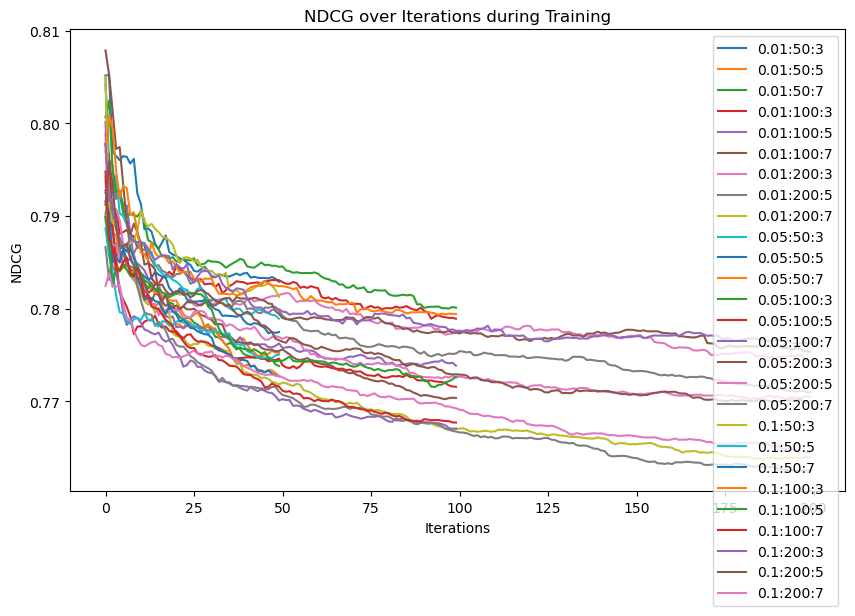

In [19]:
plt.figure(figsize=(10, 6))
for key in learning_processes:
    plt.plot(learning_processes[key], label=key)
plt.xlabel('Iterations')
plt.ylabel('NDCG')
plt.title('NDCG over Iterations during Training')
plt.legend()
plt.show()

Seems that process found more appropriate values to mode, but in general we see that learning process make results a little bit worse over iterations. Not critical, but let's use an implemented library model for comparison.

We tent to use model from **lightgbm**.

Here is an implementation:

In [102]:
df = original_df.copy()

We should apply small data processing to be able to run this model on our dataset.

In [103]:
# Only keep the required columns
df = df[['UserID', 'MovieID', 'Rating']]

# Prepare the dataset for ranking
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Combine train and test data to fit encoders on all unique values
combined = pd.concat([df_train, df_test])

# Encode the users and movies
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

# Fit the encoders on the combined dataset
combined['UserID'] = user_encoder.fit_transform(combined['UserID'])
combined['MovieID'] = item_encoder.fit_transform(combined['MovieID'])

# Split back into train and test sets
df_train['UserID'] = combined.loc[combined.index.isin(df_train.index), 'UserID']
df_train['MovieID'] = combined.loc[combined.index.isin(df_train.index), 'MovieID']

df_test['UserID'] = combined.loc[combined.index.isin(df_test.index), 'UserID']
df_test['MovieID'] = combined.loc[combined.index.isin(df_test.index), 'MovieID']

In [104]:
# Define the number of rank classes (bins)
num_classes = 31

# Re-rank and normalize the data so that ranks are within each user group and map to [0, num_classes-1]
df_train['Rank'] = df_train.groupby('UserID')['Rating'].rank(ascending=False, method='first')
df_train['Rank'] = (df_train['Rank'] - 1).astype(int)
df_train['Rank'] = pd.qcut(df_train['Rank'], q=num_classes, labels=False)

df_test['Rank'] = df_test.groupby('UserID')['Rating'].rank(ascending=False, method='first')
df_test['Rank'] = (df_test['Rank'] - 1).astype(int)
df_test['Rank'] = pd.qcut(df_test['Rank'], q=num_classes, labels=False)

# Ensure ranks are integers
df_train['Rank'] = df_train['Rank'].astype(int)
df_test['Rank'] = df_test['Rank'].astype(int)

# Create group data (number of items per user)
train_group = df_train.groupby('UserID').size().to_list()
test_group = df_test.groupby('UserID').size().to_list()

Now we will define dataset for **lightgbm** specifics.

In [105]:
# Prepare LightGBM datasets
X_train = df_train[['UserID', 'MovieID']]
y_train = df_train['Rank']
X_test = df_test[['UserID', 'MovieID']]
y_test = df_test['Rank']

lgb_train = lgb.Dataset(X_train, label=y_train, group=train_group)
lgb_test = lgb.Dataset(X_test, label=y_test, group=test_group, reference=lgb_train)

Now we can went with model learning

In [106]:
# Define the LambdaMART parameters
params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'lambdarank_truncation_level': 10,
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'verbose': -1
}

# Train the model
print("Training LambdaMART model...")
model = lgb.train(params, lgb_train, valid_sets=[lgb_test])

Training LambdaMART model...


In [107]:
# Save the model to be able re-use it if needed
model.save_model('lambdamart_model.txt')


In [108]:
# Predict scores for the test set
y_pred = model.predict(X_test)

# Evaluate the model using NDCG@10
ndcg_10 = ndcg_score([y_test], [y_pred], k=10)
print(f"NDCG@10: {ndcg_10:.4f}")

NDCG@10: 0.8834


There is huge leap forward in compatison with our custom solution.

It is learning way faster, use more optimized technics under the hood and as we see performes better.

Our maximum acheived NDCG in out model is - **0.7849**.

In LightGBM we were able to acheived - **0.8834** which is 10% better in comparison.

Also LightGBM more optimazed if we a re talking about how it handles data.

It is automatically handles missing values, categorized features and hyperparameters tuning.

Let's explore some additional metrics to use in future comparisons

In [109]:
import numpy as np
import json
from sklearn.metrics import ndcg_score

# Assuming y_test and y_pred are your test labels and predictions from the LightGBM model
# Ensure they are NumPy arrays
y_test = np.asarray(y_test)
y_pred = np.asarray(y_pred)

# Make sure y_test and y_pred are 2D arrays
if y_test.ndim == 1:
    y_test = y_test.reshape(1, -1)
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(1, -1)

# Compute Mean Reciprocal Rank (MRR)
def mean_reciprocal_rank(y_true, y_pred, k=10):
    """Calculates Mean Reciprocal Rank (MRR)"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    order = np.argsort(-y_pred, axis=1)
    y_true_sorted = np.take_along_axis(y_true, order, axis=1)
    ranks = np.argmax(y_true_sorted > 0, axis=1) + 1
    rr = 1.0 / ranks
    return np.mean(rr)

# Compute Precision@k
def precision_at_k(y_true, y_pred, k=10):
    """Calculates Precision@k"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    order = np.argsort(-y_pred, axis=1)
    y_true_sorted = np.take_along_axis(y_true, order, axis=1)
    precision = np.mean(np.sum(y_true_sorted[:, :k] > 0, axis=1) / k)
    return precision

# Compute Coverage@k
def coverage_at_k(y_true, y_pred, k=10):
    """Calculates Coverage@k"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    order = np.argsort(-y_pred, axis=1)
    y_true_sorted = np.take_along_axis(y_true, order, axis=1)
    coverage = np.mean(np.sum(y_true_sorted[:, :k] > 0, axis=1) > 0)
    return coverage

# Calculate metrics
mrr = mean_reciprocal_rank(y_test, y_pred)
precision_10 = precision_at_k(y_test, y_pred, k=10)
coverage_10 = coverage_at_k(y_test, y_pred, k=10)

# Compute NDCG@k for different values of k
k_values = [1, 3, 5, 10]
ndcg_scores = [ndcg_score(y_test, y_pred, k=k) for k in k_values]

# Collect the metrics into a dictionary
metrics = {
    "Mean Reciprocal Rank (MRR)": mrr,
    "Precision@10": precision_10,
    "Coverage@10": coverage_10,
    "NDCG@1": ndcg_scores[0],
    "NDCG@3": ndcg_scores[1],
    "NDCG@5": ndcg_scores[2],
    "NDCG@10": ndcg_scores[3]
}

# Save the metrics to a JSON file
with open('lightgbm_metrics.json', 'w') as json_file:
    json.dump(metrics, json_file, indent=4)

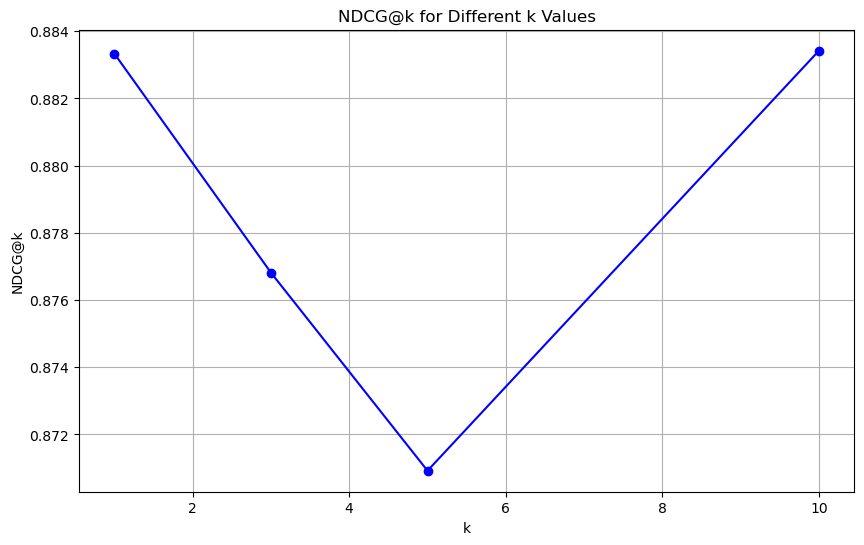

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_values, ndcg_scores, marker='o', linestyle='-', color='b')
plt.title('NDCG@k for Different k Values')
plt.xlabel('k')
plt.ylabel('NDCG@k')
plt.grid(True)
plt.show()

## RankNet Model

RankNet is a pairwise learning-to-rank algorithm developed by Microsoft Research. It uses a neural network to model the probability that one item should be ranked higher than another.

### Description
RankNet is a neural network-based learning-to-rank algorithm developed by Microsoft. The core idea behind RankNet is to model the pairwise ranking problem by learning a probability distribution over the possible rankings of pairs of items. This is achieved by training a neural network to predict whether one item should be ranked higher than another.

### Pairwise Approach
In the pairwise approach, the ranking problem is reduced to a classification problem where the model learns to predict the correct order between two items. For each pair of items $ i $ and $ j $ associated with a user, RankNet computes the difference in predicted scores:
$$
s_{ij} = f(\mathbf{x}_i) - f(\mathbf{x}_j)
$$
where $ f(\cdot) $ is the scoring function (a neural network in this case), and $ \mathbf{x}_i $ and $ \mathbf{x}_j $ are the feature representations of items $ i $ and $ j $, respectively.

### Loss Function
The loss function for RankNet is based on the cross-entropy loss, which is used to minimize the difference between the predicted ranking order and the true ranking order. The loss for a pair of items is given by:
$$
L(s_{ij}, y_{ij}) = -y_{ij} \log(\sigma(s_{ij})) - (1 - y_{ij}) \log(1 - \sigma(s_{ij}))
$$
where $ y_{ij} $ is the true label indicating whether item $ i $ should be ranked higher than item $ j $, and $ \sigma(\cdot) $ is the sigmoid function:
$$
\sigma(s_{ij}) = \frac{1}{1 + e^{-s_{ij}}}
$$
The model is trained by minimizing the loss over all pairs of items.

In [85]:
df = original_df.copy()

In [86]:
# Only keep the required columns
df = df[['UserID', 'MovieID', 'Rating']]

# Prepare the dataset for ranking
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Combine training and test sets for encoding
combined = pd.concat([df_train, df_test])

# Encode the users and movies
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

combined['UserID'] = user_encoder.fit_transform(combined['UserID'])
combined['MovieID'] = item_encoder.fit_transform(combined['MovieID'])

# Split back into training and test sets
df_train['UserID'] = combined.loc[combined.index.isin(df_train.index), 'UserID']
df_train['MovieID'] = combined.loc[combined.index.isin(df_train.index), 'MovieID']

df_test['UserID'] = combined.loc[combined.index.isin(df_test.index), 'UserID']
df_test['MovieID'] = combined.loc[combined.index.isin(df_test.index), 'MovieID']

In [87]:
# Create input pairs for RankNet
def create_pairs(df):
    X_pairs = []
    y_pairs = []
    
    grouped = df.groupby('UserID')
    for user_id, group in grouped:
        items = group['MovieID'].values
        ratings = group['Rating'].values
        
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                if ratings[i] != ratings[j]:
                    X_pairs.append((items[i], items[j]))
                    y_pairs.append(1 if ratings[i] > ratings[j] else 0)
    
    return np.array(X_pairs), np.array(y_pairs)

X_train_pairs, y_train_pairs = create_pairs(df_train)
X_test_pairs, y_test_pairs = create_pairs(df_test)

In [88]:
import torch
import torch.nn as nn
import torch.optim as optim

class RankNet(nn.Module):
    def __init__(self, n_items, embedding_dim=32):
        super(RankNet, self).__init__()
        self.embedding = nn.Embedding(n_items, embedding_dim)
        self.fc = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        x = self.embedding(x)
        x = self.fc(x)
        return x

In [89]:
# Initialize the model
n_items = combined['MovieID'].nunique()
model = RankNet(n_items)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Convert data to PyTorch tensors
X_train_pairs = torch.tensor(X_train_pairs, dtype=torch.long)
y_train_pairs = torch.tensor(y_train_pairs, dtype=torch.float32)
X_test_pairs = torch.tensor(X_test_pairs, dtype=torch.long)
y_test_pairs = torch.tensor(y_test_pairs, dtype=torch.float32)

In [90]:
# Training the model
epochs = 5
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # Predict for the pairs
    x_i = X_train_pairs[:, 0]
    x_j = X_train_pairs[:, 1]
    
    pred_i = model(x_i).squeeze()
    pred_j = model(x_j).squeeze()
    
    # Compute the loss
    loss = criterion(pred_i - pred_j, y_train_pairs)
    loss.backward()
    optimizer.step()
    
    print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 1/5, Loss: 0.6942
Epoch 2/5, Loss: 0.6935
Epoch 3/5, Loss: 0.6927
Epoch 4/5, Loss: 0.6921
Epoch 5/5, Loss: 0.6915


In [91]:
model.eval()
with torch.no_grad():
    x_i_test = X_test_pairs[:, 0]
    x_j_test = X_test_pairs[:, 1]
    
    pred_i_test = model(x_i_test).squeeze()
    pred_j_test = model(x_j_test).squeeze()
    
    correct_predictions = ((pred_i_test - pred_j_test).sign() == y_test_pairs).sum().item()
    accuracy = correct_predictions / len(y_test_pairs)
    
    print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.2653


In [93]:
def generate_full_ranking(df, model):
    grouped = df.groupby('UserID')
    user_ids = []
    predictions = []
    true_ranks = []
    
    for user_id, group in grouped:
        items = group['MovieID'].values
        ratings = group['Rating'].values
        user_tensor = torch.tensor(items, dtype=torch.long)
        
        with torch.no_grad():
            scores = model(user_tensor).squeeze().numpy()
        
        user_ids.append(user_id)
        predictions.append(scores)
        true_ranks.append(ratings)
    
    return user_ids, predictions, true_ranks

user_ids, pred_ranks, true_ranks = generate_full_ranking(df_test, model)


In [94]:
# Compute Mean Reciprocal Rank (MRR)
def mean_reciprocal_rank(y_true, y_pred):
    """Calculates Mean Reciprocal Rank (MRR)"""
    mrr = 0.0
    for true, pred in zip(y_true, y_pred):
        order = np.argsort(-pred)
        true_sorted = np.take_along_axis(true, order, axis=0)
        ranks = np.where(true_sorted > 0)[0]
        if len(ranks) > 0:
            mrr += 1.0 / (ranks[0] + 1)
    return mrr / len(y_true)

# Compute Precision@k
def precision_at_k(y_true, y_pred, k=10):
    """Calculates Precision@k"""
    precision = []
    for true, pred in zip(y_true, y_pred):
        order = np.argsort(-pred)
        true_sorted = np.take_along_axis(true, order, axis=0)
        precision.append(np.sum(true_sorted[:k] > 0) / k)
    return np.mean(precision)

# Compute Coverage@k
def coverage_at_k(y_true, y_pred, k=10):
    """Calculates Coverage@k"""
    coverage = []
    for true, pred in zip(y_true, y_pred):
        order = np.argsort(-pred)
        true_sorted = np.take_along_axis(true, order, axis=0)
        coverage.append(np.sum(true_sorted[:k] > 0) > 0)
    return np.mean(coverage)

# Calculate metrics
mrr = mean_reciprocal_rank(true_ranks, pred_ranks)
precision_10 = precision_at_k(true_ranks, pred_ranks, k=10)
coverage_10 = coverage_at_k(true_ranks, pred_ranks, k=10)

In [99]:
# Compute NDCG@k for each user and average the results
def average_ndcg_at_k(y_true, y_pred, k=10):
    """Calculates average NDCG@k for all users."""
    ndcg_scores = []
    for true, pred in zip(y_true, y_pred):
        # Check if there are more than one items to rank
        if len(true) > 1:
            ndcg = ndcg_score([true], [pred], k=k)
            ndcg_scores.append(ndcg)
    return np.mean(ndcg_scores) if ndcg_scores else 0.0

# Compute NDCG@k for different values of k
k_values = [1, 3, 5, 10]
ndcg_scores = [average_ndcg_at_k(true_ranks, pred_ranks, k=k) for k in k_values]

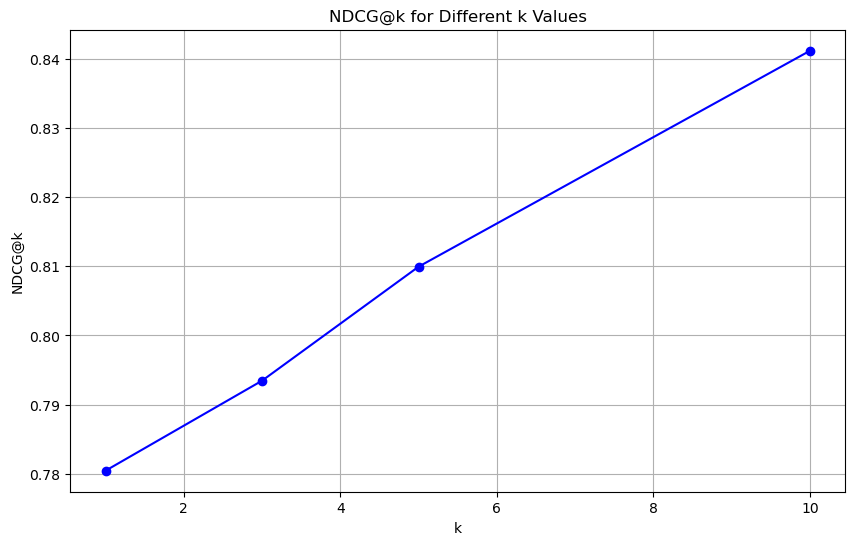

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_values, ndcg_scores, marker='o', linestyle='-', color='b')
plt.title('NDCG@k for Different k Values')
plt.xlabel('k')
plt.ylabel('NDCG@k')
plt.grid(True)
plt.show()

In [101]:
import json

# Assuming the following metrics have been calculated
metrics = {
    "Mean Reciprocal Rank (MRR)": mrr,
    "Precision@10": precision_10,
    "Coverage@10": coverage_10,
    "NDCG@1": ndcg_scores[0],
    "NDCG@3": ndcg_scores[1],
    "NDCG@5": ndcg_scores[2],
    "NDCG@10": ndcg_scores[3]
}

# Save the metrics to a JSON file
with open('ranknet_metrics.json', 'w') as json_file:
    json.dump(metrics, json_file, indent=4)

## Comparison of LightGBM and RankNet Models

Metrics Comparison:

1. Mean Reciprocal Rank (MRR):
* LightGBM: 1.0
* RankNet: 1.0
Interpretation: Both models achieve a perfect MRR score, indicating that they are consistently ranking the most relevant items at the top position.
2. Precision@10:
* LightGBM: 1.0
* RankNet: 0.889
Interpretation: LightGBM achieves perfect precision, meaning all top 10 recommendations are relevant, whereas RankNet’s precision is slightly lower, indicating that some of the top 10 recommendations may not be relevant.
3. Coverage@10:
* LightGBM: 1.0
* RankNet: 1.0
Interpretation: Both models have perfect coverage, meaning that for all users, at least one relevant item is included in the top 10 recommendations.
4. NDCG@1:
* LightGBM: 0.883
* RankNet: 0.780
Interpretation: LightGBM performs better in ranking the top item, with a higher NDCG@1, meaning the most relevant item is more often at the top in LightGBM.
5. NDCG@3:
* LightGBM: 0.877
* RankNet: 0.793
Interpretation: LightGBM continues to outperform RankNet when considering the top 3 results, indicating a stronger ability to rank the most relevant items higher.
6. NDCG@5:
* LightGBM: 0.871
* RankNet: 0.810
Interpretation: LightGBM maintains better ranking quality in the top 5 results compared to RankNet.
7. NDCG@10:
* LightGBM: 0.883
* RankNet: 0.841
Interpretation: Even at the top 10 results, LightGBM outperforms RankNet, although the difference narrows slightly.

Advantages and Disadvantages:

LightGBM:

Advantages:
* Superior Ranking Quality: LightGBM consistently outperforms RankNet across all NDCG metrics, indicating that it ranks relevant items higher overall.
* Perfect Precision: LightGBM achieved a perfect Precision@10 score, meaning all top 10 recommendations are relevant.
* High Performance: LightGBM is known for its efficiency and scalability, particularly in ranking tasks, and this is reflected in its superior metrics.
Disadvantages:
* Model Complexity: While effective, LightGBM models can be complex and harder to interpret, especially with large ensembles of trees.
* Feature Engineering: LightGBM often requires more careful feature engineering to perform optimally compared to neural networks like RankNet.

RankNet:

Advantages:
* Flexibility: RankNet, being a neural network model, can potentially capture more complex patterns and interactions in the data, given sufficient training and hyperparameter tuning.
* Neural Network Strength: RankNet may be more adaptable to complex and non-linear data patterns, which can be an advantage in more challenging ranking tasks.
Disadvantages:
* Lower Precision and NDCG Scores: RankNet performs worse than LightGBM across all NDCG metrics and Precision@10, indicating it is less effective at ranking the most relevant items higher.
* Training Complexity: Neural networks like RankNet can be harder to train effectively, requiring more computational resources and fine-tuning of hyperparameters.

## Summary:

* Performance: LightGBM outperforms RankNet across all metrics, particularly in NDCG and Precision@10, making it the better choice for ranking tasks in this dataset.
* Use Case: LightGBM is preferred for tasks where high ranking accuracy and efficiency are critical. RankNet, on the other hand, might be more suitable in scenarios where capturing complex relationships is more important and where neural networks are better suited.
* Final Consideration: While RankNet offers flexibility and potential in certain complex scenarios, LightGBM’s superior performance in standard ranking tasks, especially in terms of ranking quality (NDCG) and precision, makes it the stronger choice for this dataset.